# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 05: Regressão**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_05_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>R. Quinlan. "Auto MPG," UCI Machine Learning Repository, 1993. https://doi.org/10.24432/C5859H.</font>

Automóveis e seu consumo de combustível / definir o consumo de combustível de carros em galões / reais, categoricos e inteiros.

## <font color='green'>Preparação</font>

In [11]:
!pip install pandas scikit-learn ucimlrepo

In [10]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importar o dataset Auto MPG (ID 9)
auto_mpg = fetch_ucirepo(id=9)

# Extrair as variáveis independentes (X) e a variável alvo (y)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# Ver as primeiras linhas
display(X.head())

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1


## <font color='green'>**1. Análise Exploratória de Dados (EDA)**</font>

### <font color='cyan'>Q1) Verifique se há amostras com valores ausentes no conjunto de dados. Se houver, remova-as e informe quantas foram removidas.</font>

In [8]:
falta = X.isnull().any(axis=1).sum()

X = X.dropna()

print(falta)

0


### <font color='cyan'>Q2) Plote um histograma da coluna alvo `y` (MPG) utilizando `matplotlib` ou `seaborn`. Adicione título e rótulos aos eixos.</font>

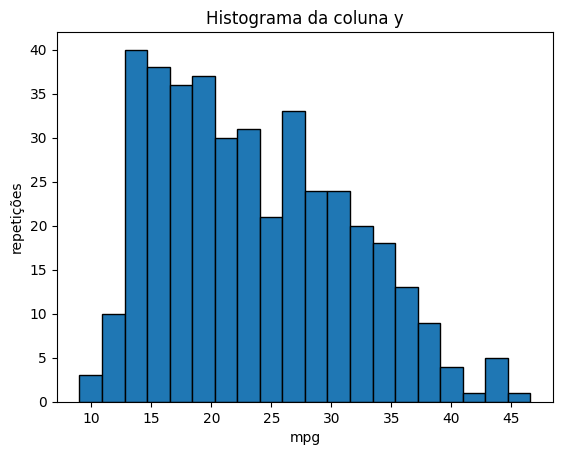

In [7]:
plt.hist(y['mpg'], bins=20, edgecolor='black')

plt.title('Histograma da coluna y')
plt.xlabel('mpg')
plt.ylabel('repetições')

plt.show()

### <font color='cyan'>Q3) O que a distribuição do histograma nos diz sobre o consumo de combustível da maioria dos carros desse dataset?</font>

Pela maior concentração se encontrar entre 15 e 20, oque mostra que boa parte dos carros tem consumo medio de combustível,

## <font color='green'>**2. Regressão Linear, Polinomial e Visualização**</font>

### <font color='cyan'>Q4) Crie um gráfico de dispersão (scatter plot) de `weight` vs `mpg`.</font>

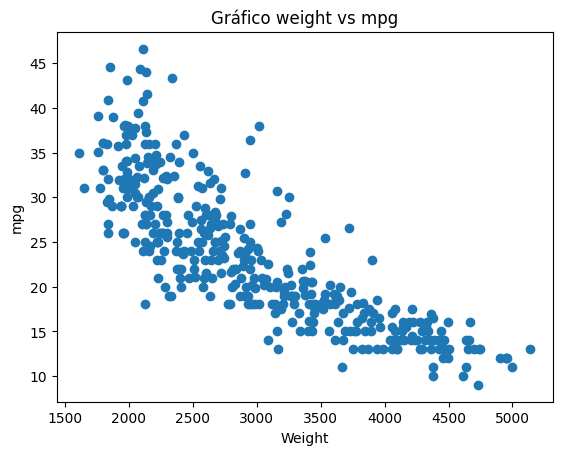

In [12]:
plt.scatter(X['weight'], y['mpg'])
plt.title('Gráfico weight vs mpg')
plt.xlabel('Weight')
plt.ylabel('mpg')
plt.show()

### <font color='cyan'>Q5) Observando o gráfico de dispersão gerado na questão anterior, como você descreveria a relação entre o peso do veículo (weight) e o consumo de combustível (mpg)? A relação parece ser estritamente linear ou apresenta um comportamento não linear? Justifique sua resposta.</font>

Com base no gráfico plotado, podemos dizer que a medida que o peso do veiculo aumenta, o valor de mpg diminui, logo, carros mais pesados possuem uma tendência a consumir mais combustível, fazendo menos km/galão.

### <font color='cyan'>Q6) Divida o conjunto de dados em treinamento (80%) e teste (20%), utilizando a variável `weight` como entrada e `mpg` como alvo, e em seguida construa um gráfico de dispersão que apresente os dois subconjuntos com cores diferentes, incluindo título, rótulos dos eixos e uma legenda para identificar claramente os dados de treino e de teste.</font>

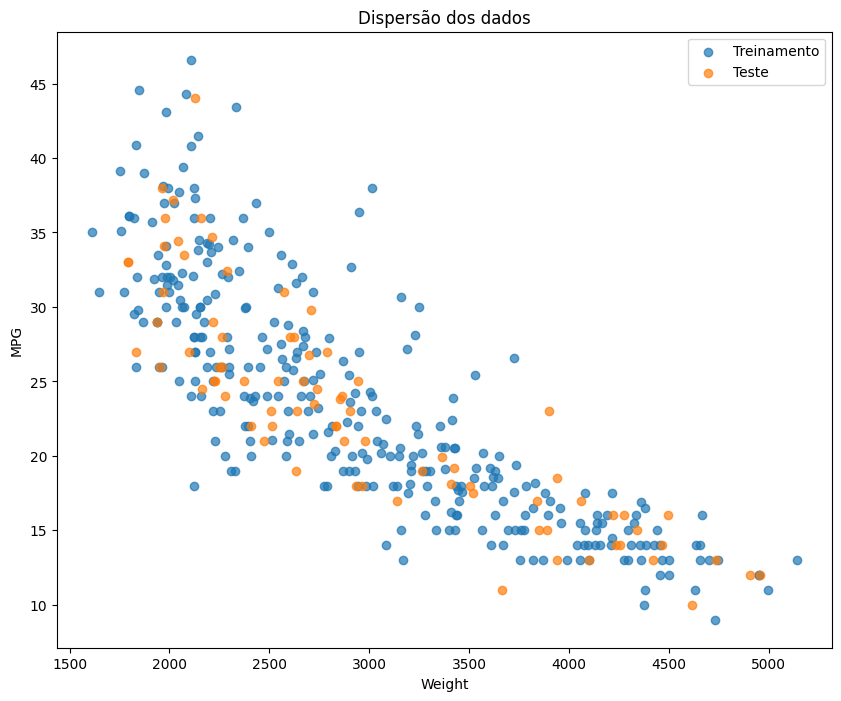

In [13]:
from sklearn.model_selection import train_test_split

xw = X[['weight']]
ym = y['mpg']
treinox, xt, treinoy, yt = train_test_split(
    xw, ym, test_size=0.2, random_state=42
)

plt.figure(figsize=(10,8))
plt.scatter(treinox, treinoy, label='Treinamento', alpha=0.7)
plt.scatter(xt, yt, label='Teste', alpha=0.7)

plt.title('Dispersão dos dados')

plt.xlabel('Weight')
plt.ylabel('MPG')
plt.legend()

plt.show()

### <font color='cyan'>Q7) Com base na distribuição dos pontos no gráfico gerado, os conjuntos de treinamento e teste parecem ser representativos do conjunto de dados original? Justifique sua resposta observando a dispersão das cores.</font>

Sim, os dados parecem ser representativos, conforme o weight aumenta, o mpg diminui, os pontos das duas cores estão bem espalhados ao longo de toda a distribuição dos dados, unindo isso ao fato dos pontos de teste não ficaram concentrados em apenas uma região do gráfico.

### <font color='green'>Antes de avaliarmos nosso modelo, vamos entender brevemente o que cada métrica significa e quais funções da biblioteca [`sklearn.metrics`](https://scikit-learn.org/stable/api/sklearn.metrics.html) utilizaremos:</font>
- #### <font color='green'>R² (Coeficiente de Determinação) - função `r2_score(y_true, y_pred)`: Mede o quão bem o modelo se ajusta aos dados. Ele indica a proporção da variabilidade da variável alvo (MPG) que é explicada pelo modelo. Varia geralmente de 0 a 1 (podendo ser negativo se o modelo for pior que uma linha média). Quanto mais próximo de 1, melhor.</font>
- #### <font color='green'>MAE (Erro Absoluto Médio - Mean Absolute Error) - função `mean_absolute_error(y_true, y_pred)`: Representa a média das diferenças em valor absoluto entre as previsões do modelo e os valores reais. É uma métrica muito intuitiva porque o erro é retornado na mesma unidade da variável alvo (ou seja, errar por "3 MPG"). Quanto menor, melhor.</font>
- #### <font color='green'>MSE (Erro Quadrático Médio - Mean Squared Error) - função `mean_squared_error(y_true, y_pred)`: Calcula a média dos erros elevados ao quadrado. Como os erros são elevados ao quadrado, o MSE penaliza erros maiores (outliers) de forma mais severa do que o MAE. Quanto menor, melhor.</font>

### <font color='cyan'>Q8) Importe as funções `r2_score`, `mean_absolute_error` e `mean_squared_error` do módulo `sklearn.metrics`. Em seguida, treine um modelo de Regressão Linear Simples para prever o MPG usando o peso. Faça as previsões para o conjunto de treinamento e para o conjunto de teste. Por fim, imprima as métricas (R², MAE e MSE) para ambos os conjuntos.</font>

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

m = LinearRegression()
m.fit(treinox, treinoy)

ypred = m.predict(treinox)
ytest = m.predict(xt)
r2 = r2_score(treinoy, ypred)
mae = mean_absolute_error(treinoy, ypred)
mse = mean_squared_error(treinoy, ypred)
r2teste = r2_score(yt, ytest)
maeteste = mean_absolute_error(yt, ytest)
mseteste = mean_squared_error(yt, ytest)

print(r2)
print(r2teste)
print(mae)
print(maeteste)
print(mse)
print(mseteste)

0.6844798112332582
0.722971057303075
3.359294297635544
3.1177861992064573
19.781923945400305
14.894861064636194


### <font color='cyan'>Q9) Compare os erros (MAE e MSE) obtidos no conjunto de treinamento com os erros do conjunto de teste. Com base nessa comparação e no conceito de viés/variância, o modelo parece estar sofrendo de subajuste (underfitting), sobreajuste (overfitting) ou apresenta um bom ajuste? Justifique.</font>

Tanto os erros MAE, quanto os de MSE dos conjuntos de teste e treinamento ficaram extremamente próximos, mostrando que o modelo generaliza de forma consistente e sem sobreajuste.

### <font color='cyan'>Q10) Treine um modelo de Regressão Polinomial (grau 2) para prever o MPG usando o peso. em seguida, Assim como na questão anterior, faça previsões e imprima as métricas (R², MAE e MSE) para os conjuntos de treinamento e de teste.</font>
- #### <font color='cyan'>Dica: Como as características polinomiais elevam os valores ao quadrado, a escala dos dados muda drasticamente. Utilize a classe `Pipeline` do Scikit-Learn para encadear a criação de `PolynomialFeatures(degree=2)`, a normalização com StandardScaler e o modelo LinearRegression.<font>

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

m = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

m.fit(treinox, treinoy)

ypred = m.predict(treinox)
ytest = m.predict(xt)

r2 = r2_score(treinoy, ypred)
mae = mean_absolute_error(treinoy, ypred)
mse = mean_squared_error(treinoy, ypred)

r2teste = r2_score(yt, ytest)
maeteste = mean_absolute_error(yt, ytest)
mseteste = mean_squared_error(yt, ytest)

print(r2)
print(r2teste)
print(mae)
print(maeteste)
print(mse)
print(mseteste)

0.7055159034461649
0.7554139494157487
3.1528725509013342
2.7988739891734165
18.463040428340204
13.150522130772805


### <font color='cyan'>Q11) Avaliando os erros de treinamento e teste deste modelo polinomial (grau 2), como ele se compara ao modelo linear da questão anterior? Ele apresenta sinais de underfitting, overfitting ou um bom ajuste aos dados? Justifique.</font>

O modelo polinomial de grau 2 apresentou desempenho superior ao modelo linear simples, com maior R² e menores erros MAE e MSE. Além disso, as métricas de treinamento e teste permaneceram próximas, indicando que o modelo generaliza bem para dados não vistos. Portanto, ele não apresenta sinais fortes de underfitting nem de overfitting, mas sim um bom ajuste aos dados, capturando melhor a relação não linear entre peso e consumo de combustível.

### <font color='cyan'>Q12) Utilizando os modelos já treinados, construa um gráfico de dispersão com os dados reais de treinamento e teste (`weight` vs `mpg`), diferenciando-os por cores, e sobreponha, no mesmo gráfico, as curvas de predição dos modelos de Regressão Linear Simples e Regressão Polinomial (grau 2), incluindo título, rótulos dos eixos e legenda para identificar os subconjuntos e cada regressão.</font>

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


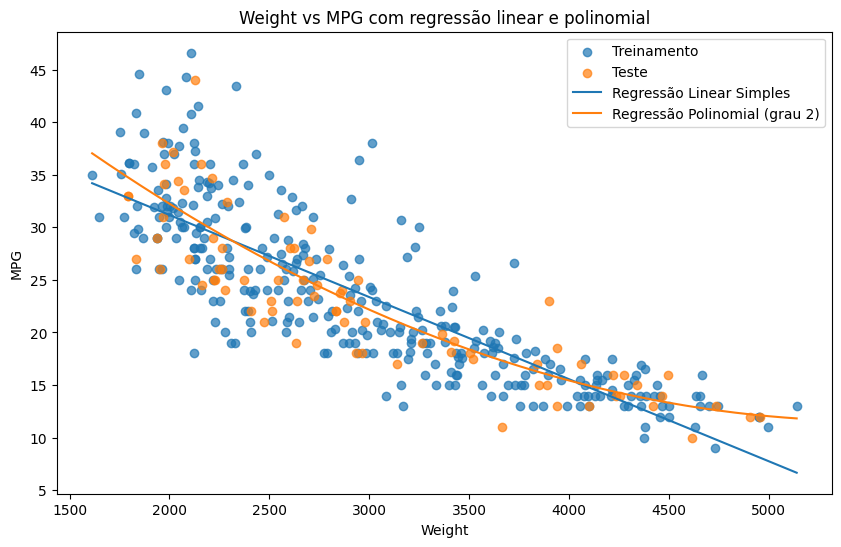

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

m_linear = LinearRegression()
m_linear.fit(treinox, treinoy)

m_poli = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

m_poli.fit(treinox, treinoy)

peso_linha = np.linspace(X['weight'].min(), X['weight'].max(), 300).reshape(-1, 1)

pred_linear = m_linear.predict(peso_linha)
pred_poli = m_poli.predict(peso_linha)

plt.figure(figsize=(10, 6))
plt.scatter(treinox, treinoy, label='Treinamento', alpha=0.7)
plt.scatter(xt, yt, label='Teste', alpha=0.7)
plt.plot(peso_linha, pred_linear, label='Regressão Linear Simples')
plt.plot(peso_linha, pred_poli, label='Regressão Polinomial (grau 2)')

plt.title('Weight vs MPG com regressão linear e polinomial')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.legend()
plt.show()

### <font color='cyan'>Q13) Com base no gráfico gerado, qual modelo parece se ajustar melhor aos dados? A relação entre `weight` e `mpg` parece ser linear ou não linear? Explique.</font>

O melhor seria a Regressão Polinomial de grau 2, porque a curva polinomial acompanha melhor o comportamento dos pontos ao longo do gráfico.

### <font color='cyan'>Q14) Os resultados observados no gráfico são consistentes com a análise das métricas? Explique possíveis diferenças entre a avaliação quantitativa (métricas) e a avaliação visual do ajuste dos modelos.</font>

Sim, pois antes, o modelo polinomial já havia apresentado valores melhores de R2 e menores erros mae e mse, indicando melhor desempenho. Na parte gráfica, isso aparece visualmente na curva polinomial, que acompanha os pontos de forma melhor que a reta da regressão linear.

### <font color='cyan'>Q15) Para observar o efeito do sobreajuste (overfitting) na prática, treine um novo modelo de Regressão Polinomial, mas desta vez utilizando um grau bem alto (por exemplo, grau 15 ou 20). Utilize o mesmo processo com o Pipeline (incluindo o escalonamento). Imprima as métricas de treinamento e teste. O que acontece com o desempenho no conjunto de teste em comparação ao de treinamento? Explique o fenômeno ocorrido.</font>

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

m = Pipeline([
    ('poly', PolynomialFeatures(degree=15)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])
m.fit(treinox, treinoy)

ypred = m.predict(treinox)
ytest = m.predict(xt)

r2 = r2_score(treinoy, ypred)
mae = mean_absolute_error(treinoy, ypred)
mse = mean_squared_error(treinoy, ypred)
r2teste = r2_score(yt, ytest)
maeteste = mean_absolute_error(yt, ytest)
mseteste = mean_squared_error(yt, ytest)

print(r2)
print(r2teste)
print(mae)
print(maeteste)
print(mse)
print(mseteste)

0.7092181029096951
0.7687810507972079
3.1413815880574565
2.693278706100443
18.23092650718507
12.431820626246026


## <font color='green'>**3. Otimização com Gradiente Descendente**</font>

### <font color='cyan'>Q16) Tente treinar um `SGDRegressor` diretamente nos dados originais de `X` (removendo valores nulos se houver) e observe o erro.</font>

In [22]:
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.concat([X, y], axis=1)

df = df.replace("?", np.nan)
df = df.dropna()
xlimpo = df[X.columns]
ylimpo = df['mpg']

xpeso = xlimpo[['weight']]
treinox, xt, treinoy, yt = train_test_split(xpeso, ylimpo, test_size=0.2, random_state=42)

m = SGDRegressor(random_state=42)
m.fit(treinox, treinoy)

ypred = m.predict(treinox)
ytest = m.predict(xt)

r2 = r2_score(treinoy, ypred)
mae = mean_absolute_error(treinoy, ypred)
mse = mean_squared_error(treinoy, ypred)

r2teste = r2_score(yt, ytest)
maeteste = mean_absolute_error(yt, ytest)
mseteste = mean_squared_error(yt, ytest)

print(r2)
print(r2teste)
print(mae)
print(maeteste)
print(mse)
print(mseteste)

-1.721884785033037e+29
-2.0886023060684893e+29
3173120470805658.5
3128088472607351.0
1.0865048913420452e+31
1.0660347985786357e+31


### <font color='cyan'>Q17) Agora, aplique o `StandardScaler` do Scikit-Learn nos dados e treine o `SGDRegressor` novamente.</font>

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

scaler = StandardScaler()

treinox_padrao = scaler.fit_transform(treinox)
xt_padrao = scaler.transform(xt)

m = SGDRegressor(random_state=42)
m.fit(treinox_padrao, treinoy)

ypred = m.predict(treinox_padrao)
ytest = m.predict(xt_padrao)

r2 = r2_score(treinoy, ypred)
mae = mean_absolute_error(treinoy, ypred)
mse = mean_squared_error(treinoy, ypred)

r2teste = r2_score(yt, ytest)
maeteste = mean_absolute_error(yt, ytest)
mseteste = mean_squared_error(yt, ytest)

print(r2)
print(r2teste)
print(mae)
print(maeteste)
print(mse)
print(mseteste)

0.6981622846131954
0.6550200418365147
3.282911638124987
3.451716349432937
19.045882570649415
17.607978270728655


### <font color='cyan'>Q18) Compare os resultados das duas abordagens e explique por que a normalização é importante para algoritmos baseados em gradiente descendente. Relacione sua resposta com o comportamento do gradiente e a escala das variáveis.</font>

Sem normalização, o SGDRegressor apresentou desempenho péssimo, com métricas instáveis e erros gigantescos. Após aplicar o StandardScaler, o modelo passou a apresentar resultados coerentes e muito melhores. Isso ocorre porque algoritmos baseados em gradiente descendente são sensíveis à escala das variáveis: quando os atributos têm magnitudes muito diferentes, o gradiente fica desbalanceado, dificultando a convergência. A normalização coloca os dados em escalas semelhantes, estabilizando as atualizações dos pesos e melhorando o treinamento.

## <font color='green'>**4. Validação Cruzada e Regularização (LASSO)**</font>

### <font color='green'>A Regressão LASSO (Least Absolute Shrinkage and Selection Operator) é uma evolução da Regressão Linear tradicional. Na regressão comum, o modelo foca apenas em reduzir o erro. O problema é que, ao tentar usar todas as variáveis disponíveis, ele pode acabar decorando ruídos e gerando overfitting. O LASSO resolve isso adicionando uma penalidade aos coeficientes (pesos) das variáveis.</font>
- #### <font color='green'>O grande diferencial da regularização do LASSO (chamada de L1) é que ela consegue forçar os coeficientes de variáveis inúteis ou redundantes a se tornarem exatamente zero. Ou seja, o próprio modelo decide quais dados ignorar, entregando uma equação final mais simples, limpa e interpretável.</font>
- #### <font color='green'>O hiperparâmetro `alpha` é o "botão de volume" da penalidade. Se alpha = 0, temos uma regressão linear normal. Quanto maior o valor de alpha, mais severa é a penalização e mais atributos o modelo irá descartar.</font>

### <font color='green'>Caso queira entender a matemática por trás da função de custo, consulte os seguintes materiais:</font>
- #### <font color='green'>Anexo III do [material  teórico](https://github.com/zz4fap/c24_inteligencia_artificial/blob/main/slides/C24_Regress%C3%A3o.pdf) da disciplina  (slides 96 em diante);</font>
- #### <font color='green'>Documentação oficial do Scikit-Learn sobre [modelos lineares com LASSO](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html);</font>
- #### <font color='green'>Vídeo ["Regularization Part 2: Lasso (L1) Regression"](https://www.youtube.com/watch?v=NGf0voTMlcs), do canal "StatQuest with Josh Starmer", com uma explicação didática e visual sobre como a matemática do LASSO zera os coeficientes.</font>

### <font color='cyan'>Q19) O algoritmo LASSO é extremamente sensível à escala dos dados, pois ele penaliza a magnitude bruta dos coeficientes. Crie um `Pipeline` que aplique o `StandardScaler` e, em seguida, o modelo `Lasso(alpha=1.0)`. Treine-o com todos os dados (`X` e `y`) e exiba os coeficientes finais. A aplicação da normalização mudou a relevância que o modelo deu às variáveis em comparação com a Q16 (onde não usamos normalização)? Explique.</font>

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

df = pd.concat([X, y], axis=1)

df = df.replace("?", np.nan)
df = df.dropna()
xlimpo = df[X.columns]
ylimpo = df['mpg']

final = pd.get_dummies(xlimpo, drop_first=True)

m = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=1.0))
])
m.fit(final, ylimpo)
coef = pd.Series(m.named_steps['lasso'].coef_, index=final.columns)
coef

,0
displacement,-0.000000
cylinders,-0.000000
horsepower,-0.167700
weight,-4.545532
acceleration,0.000000
model_year,1.994436
origin,0.308290


### <font color='cyan'>Q20) O hiperparâmetro alpha é quem dita a força da regularização. Utilizando o mesmo processo com o Pipeline e o StandardScaler, treine três modelos LASSO distintos, alterando o valor de alpha para: 0.1, 1.0 e 5.0. Imprima apenas os nomes das variáveis que "sobreviveram" (ou seja, que tiveram coeficientes diferentes de zero) em cada modelo. O que acontece com a complexidade do modelo à medida que o valor de alpha aumenta?</font>

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

df = pd.concat([X, y], axis=1)
df = df.replace("?", np.nan)
df = df.dropna()
xlimpo = df[X.columns]
ylimpo = df['mpg']

final = pd.get_dummies(xlimpo, drop_first=True)

alphas = [0.1, 1.0, 5.0]

for a in alphas:
    m = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=a))
    ])

    m.fit(final, ylimpo)
    coef = m.named_steps['lasso'].coef_
    s = final.columns[coef != 0]
    print(list(s))
    print()

['horsepower', 'weight', 'acceleration', 'model_year', 'origin']

['horsepower', 'weight', 'model_year', 'origin']

['weight']

